In [40]:
import glob
import os
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from typing import List
from flights_io  import get_matched_flights
from flight_processing import process_flight

In [41]:
#Teste code

In [48]:
base_dir = "/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/work/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/work/SAM

In [49]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))

    return dsf

In [50]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [51]:
def calculate_absortion_eff(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    common_times = np.intersect1d(filtered_time, psap_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_psap_matched = aux_ds_psap.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_psap_matched,total_mass_matched

In [52]:
def Area_plot(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    # Define time axis (assuming all datasets have the same time dimension)
    time = total_mass.datetime.values
    
    # Extract variables
    bc_mass = bc_mass_interp
    so4 = filtered_ds_SO4["SO4"]
    nh4 = filtered_ds_NH4["NH4"]
    org = filtered_ds_ORG["ORG"]
    no3 = filtered_ds_NO3["NO3"]
    chl = filtered_ds_Chl["Chl"]

    
    #filtered_time = total_mass.datetime.values  # Reference timestamps
    #psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    # Stack the values
    data = [bc_mass, so4, nh4, org, no3, chl]
    
    return time,data


In [53]:
def parse_flight_log(lines):
    extracted_data = []
    
    for line in lines[2:]:  # Skip headers
        parts = re.split(r'\s{2,}', line.strip())  # Split on 2+ spaces
        
        if len(parts) < 2:
            continue  # Skip lines with insufficient data
        
        start_time = parts[0]  # First column is always Start Time

        # Check if second column is numeric (End Time), if so, event is at index 2
        if len(parts) > 2 and parts[1].isdigit():
            event = parts[2]  # Third column is the event
        else:
            event = parts[1]  # Otherwise, second column is the event

        extracted_data.append([start_time, event])  # Append as list (not tuple)
        
    return np.array(extracted_data)  # Convert to NumPy array

In [54]:
def flight_comments_df(file_path_flight_comm):
    # Read the file
    with open(file_path_flight_comm, "r") as file:
        lines = file.readlines()
    # Process and print output
    parsed_data = parse_flight_log(lines)
    
    start_time_col = parsed_data[3:, 0]  # First column
    event_col = parsed_data[3:, 1]  # Second column

    # Create DataFrame
    df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

    
    return df_flight

In [55]:
def plot_flight_data_v6_test(
    flight_number, flight_date,
    area_time, data_mass_concentration,
    filtered_ds_psap_aux,   # kept for compatibility, not used
    ds_neph_datetime, ds_neph_TSC_BLUU,
    ds_psap, df_flight,
    outdir=".",
):
    """
    Slide-style figure (16:9, no absorption panel).

    Panels:
      (a) stacked aerosol mass composition
      (b) altitude (GPS_ALT)
      (c) blue scattering coefficient (nephelometer)

    Notes
    -----
    - Keeps the same function signature as the original for drop-in compatibility.
    - `filtered_ds_psap_aux` is intentionally unused.
    """

    # ---------------------------
    # Styling for slideshow plots
    # ---------------------------
    plt.rcParams.update({
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
        "figure.titlesize": 24,
        "axes.linewidth": 1.4,
    })

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(13.333, 7.5),   # 16:9 widescreen
        sharex=True,
        constrained_layout=True
    )

    # Scientific formatter for y-axes where appropriate
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    # ---------------------------
    # Start-up time for x-limits
    # ---------------------------
    df_flight = df_flight.copy()
    df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")
    df_flight["Start Time"] = df_flight["Start Time"].apply(
        lambda t: pd.Timestamp(flight_date) + pd.Timedelta(
            hours=t.hour, minutes=t.minute, seconds=t.second
        )
    )

    start_up_time = df_flight.loc[df_flight["Event"] == "Start-Up", "Start Time"].iloc[0]
    end_time = pd.to_datetime(ds_psap["Time"].values[-1])

    panel_labels = ["(a)", "(b)", "(c)"]

    # ---------------------------
    # (a) Stacked composition
    # ---------------------------
    ax1 = axes[0]
    labels = ["BC", "SO₄²⁻", "NH₄⁺", "Org", "NO₃⁻"]
    colors = ["black", "red", "orange", "green", "navy"]

    ax1.stackplot(
        area_time,
        data_mass_concentration,
        labels=labels,
        colors=colors,
        alpha=0.85
    )
    ax1.set_ylabel(r"Mass conc. ($\mu g\,m^{-3}$)")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.grid(True, which="major", alpha=0.25, linewidth=0.8)
    ax1.legend(
        loc="upper right",
        ncol=5,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.0
    )
    ax1.text(
        0.01, 0.90, panel_labels[0],
        transform=ax1.transAxes,
        fontweight="bold",
        fontsize=18
    )
    ax1.set_xlim(start_up_time, end_time)

    # ---------------------------
    # (b) Altitude
    # ---------------------------
    ax2 = axes[1]
    ax2.plot(
        ds_psap["Time"],
        ds_psap["GPS_ALT"],
        linestyle="none",
        marker=".",
        markersize=3.5,
        color="0.2",
        alpha=0.8
    )
    ax2.set_ylabel("Altitude (m)")
    ax2.grid(True, which="major", alpha=0.25, linewidth=0.8)
    ax2.text(
        0.01, 0.90, panel_labels[1],
        transform=ax2.transAxes,
        fontweight="bold",
        fontsize=18
    )
    ax2.set_xlim(start_up_time, end_time)

    # ---------------------------
    # (c) Blue scattering coefficient
    # ---------------------------
    ax3 = axes[2]
    sca_blue = ds_neph_TSC_BLUU * 1e6

    ax3.plot(
        ds_neph_datetime,
        sca_blue,
        linewidth=2.5,
        color="tab:blue",
        alpha=0.95
    )
    ax3.set_ylabel(r"$\sigma_{sca,blue}$ ($Mm^{-1}$)")
    ax3.set_xlabel("Time (UTC)")
    ax3.yaxis.set_major_formatter(formatter)
    ax3.grid(True, which="major", alpha=0.25, linewidth=0.8)
    ax3.text(
        0.01, 0.90, panel_labels[2],
        transform=ax3.transAxes,
        fontweight="bold",
        fontsize=18
    )
    ax3.set_xlim(start_up_time, end_time)

    if np.isfinite(np.nanmax(sca_blue)):
        ax3.set_ylim(0, np.nanmax(sca_blue) * 1.10)

    # ---------------------------
    # Shared x-axis formatting
    # ---------------------------
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=1))

    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.margins(x=0)

    # Figure title
    fig.suptitle(f"Flight {flight_number} ({flight_date})", y=1.02)

    # Save
    #os.makedirs(outdir, exist_ok=True)
    #outpath = os.path.join(outdir, f"flight_{flight_number}_slide.png")
    #plt.savefig(outpath, dpi=300, bbox_inches="tight")
    #print(f"Figure saved as {outpath}")

    return fig, axes

In [56]:
def plot_flight_data_v7_window(
    flight_number, flight_date,
    area_time, data_mass_concentration,
    filtered_ds_psap_aux,
    ds_neph_datetime, ds_neph_TSC_BLUU,
    ds_psap, df_flight,
    t_start, t_end,   # NEW: window definition
):

    # ---------------------------
    # Style (more publication-like)
    # ---------------------------
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.2,
    })

    # ---------------------------
    # Time window mask
    # ---------------------------
    t_start = pd.to_datetime(t_start)
    t_end   = pd.to_datetime(t_end)

    mask_alt  = (ds_psap["Time"] >= t_start) & (ds_psap["Time"] <= t_end)

    # ---------------------------
    # Figure layout
    # ---------------------------
    fig = plt.figure(figsize=(10, 6))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8])

    ax1 = fig.add_subplot(gs[0, 0])  # stack
    ax2 = fig.add_subplot(gs[0, 1])  # scattering
    ax3 = fig.add_subplot(gs[1, :])  # altitude

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))

    # ---------------------------
    # (a) STACKED (windowed)
    # ---------------------------
    # ---------------------------
    # (a) Stacked composition
    # ---------------------------

    labels = ["BC", "SO₄²⁻", "NH₄⁺", "Org", "NO₃⁻"]
    panel_labels = ["(a)", "(b)", "(c)"]

    # Colorblind-safe-ish palette (important improvement)
    #colors = ["#000000", "#D55E00", "#E69F00", "#009E73", "#0072B2"]
    colors = ["black", "red", "orange", "green", "navy"]

    ax1.stackplot(
        area_time,
        data_mass_concentration,
        labels=labels,
        colors=colors,
        alpha=0.9
    )

    ax1.set_ylabel(r"Mass conc. ($\mu g\,m^{-3}$)")
    ax1.set_xlim(t_start, t_end)
    ax1.set_ylim(0, 30)
    ax1.yaxis.set_major_formatter(formatter)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))

    ax1.legend(ncol=3, frameon=False)
    #ax1.set_title("(a) Aerossol Composition")
    ax1.text(
        0.01, 0.90, panel_labels[0],
        transform=ax1.transAxes,
        fontweight="bold",
        fontsize=15
    )

    # ---------------------------
    # (b) SCATTERING (windowed)
    # ---------------------------
    sca_blue = ds_neph_TSC_BLUU * 1e6

    ax2.plot(
        ds_neph_datetime,
        sca_blue,
        color="#0072B2",
        linewidth=2
    )

    ax2.set_ylabel(r"$\sigma_{sca,green}$ ($Mm^{-1}$)")
    ax2.set_xlim(t_start, t_end)
    ax2.set_ylim(0, 150)
    ax2.yaxis.set_major_formatter(formatter)
    #ax2.set_title("(b) Scattering")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
    ax2.text(
        0.01, 0.90, panel_labels[1],
        transform=ax2.transAxes,
        fontweight="bold",
        fontsize=15
    )

    # ---------------------------
    # (c) ALTITUDE (full + highlighted window)
    # ---------------------------
    ax3.plot(
        ds_psap["Time"],
        ds_psap["GPS_ALT"],
        color="0.4",
        linewidth=1.4,
        label="Flight altitude"
    )

    # Background highlight (time window)
    ax3.axvspan(
        t_start,
        t_end,
        color="#D55E00",
        alpha=0.15,
        zorder=0,
        label="Selected window"
    )

    ax3.set_xlim(
        pd.Timestamp(f"{flight_date} 12:00:00"),
        pd.Timestamp(f"{flight_date} 16:10:00")
    )

    ax3.set_ylabel("Altitude (m)")
    ax3.set_xlabel("Time (UTC)")
    #ax3.grid(alpha=0.2)

    ax3.legend(frameon=False)
    #ax3.set_title("(c) Flight altitude")
    # ---------------------------
    # X-axis formatting
    # ---------------------------
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax3.text(
        0.01, 0.90, panel_labels[2],
        transform=ax3.transAxes,
        fontweight="bold",
        fontsize=15
    )

    # Clean spines
    for ax in [ax1, ax2, ax3]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ---------------------------
    # Title
    # ---------------------------
    fig.suptitle(f"Flight {flight_number} ({flight_date})", y=0.98)

    return fig, (ax1, ax2, ax3)

In [57]:
print('test')

test


In [78]:
def plot_vertical_profile_v1(ORG, ALT, TSC_GREEN):  # index of "Org" in your stack):

    # ---------------------------
    # Style (consistent with previous)
    # ---------------------------
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.2,
    })

    # ---------------------------
    # Time window
    # ---------------------------

    # ---------------------------
    # Extract variables
    # ---------------------------
    org = ORG
    alt_org = ALT

    sca = TSC_GREEN
    alt_sca = ALT

    # Align lengths safely (important)
    #min_len_org = min(len(org), len(alt_org))
    #org = org[:min_len_org]
    #alt_org = alt_org[:min_len_org]

    #min_len_sca = min(len(sca), len(alt_sca))
    #sca = sca[:min_len_sca]
    #alt_sca = alt_sca[:min_len_sca]

    # ---------------------------
    # Figure layout
    # ---------------------------
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(10, 5),
        sharey=True,
        constrained_layout=True
    )

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))

    panel_labels = ["(a)", "(b)"]

    # ---------------------------
    # (a) Organics vs altitude
    # ---------------------------
    ax1.scatter(
        org,
        alt_org,
        s=10,
        color="#009E73",
        alpha=0.7
    )

    ax1.set_xlabel(r"OA ($\mu g\,m^{-3}$)")
    ax1.set_ylabel("Altitude (m)")
    ax1.grid(alpha=0.2)

    ax1.text(
        0.95, 0.95, panel_labels[0],
        transform=ax1.transAxes,
        fontweight="bold"
    )

    # ---------------------------
    # (b) Scattering vs altitude
    # ---------------------------
    ax2.scatter(
        sca,
        alt_sca,
        s=10,
        color="#0072B2",
        alpha=0.7
    )

    ax2.set_xlabel(r"$\sigma_{sca,green}$ ($Mm^{-1}$)")
    ax2.grid(alpha=0.2)

    ax2.text(
        0.95, 0.95, panel_labels[1],
        transform=ax2.transAxes,
        fontweight="bold"
    )

    # ---------------------------
    # Clean spines
    # ---------------------------
    for ax in [ax1, ax2]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ---------------------------
    # Title
    # ---------------------------
    #fig.suptitle(f"Flight {flight_number} ({flight_date})", y=0.98)

    return fig, (ax1, ax2)

b734


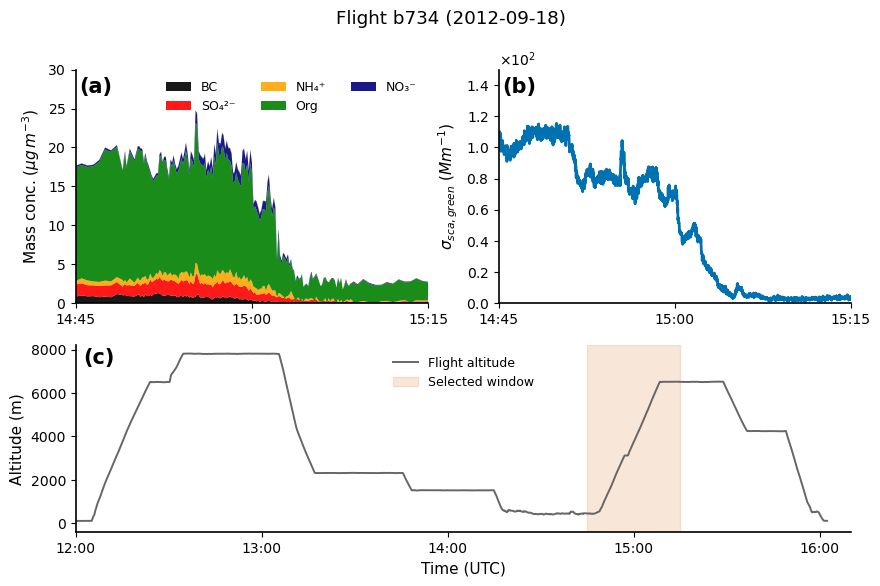

In [65]:
for flight in flights[0:1]:

    ds_sp2, ds_ams, ds_neph = dataset_sp2_ams_neph(
        flight.sp2, flight.ams, flight.neph
    )

    ds_core = xr.open_dataset(flight.core)
    print(flight.flight_id)

    #Calculate absortion efficiency 
    ds_test,tm_test=calculate_absortion_eff(ds_sp2,ds_ams,ds_core)

    #Extract concentration data
    area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_core)

    #print(data_mass_concentration.mean(dim='bc_mass'))

    #Filter absortion data
    valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
    filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = ds_test.where(valid_PSAP_mask, drop=True)
    # Ensure both arrays are 1D and aligned
    psap_values = filtered_ds_psap["PSAP_LIN"].values.squeeze()
    tm_values = tm_test.squeeze()


    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', flight.core)  # Looks for 8 consecutive digits
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"
    df_flight = flight_comments_df(flight.summary)

    t_start = pd.Timestamp(f"{flight_date} 14:45:00")
    t_end   = pd.Timestamp(f"{flight_date} 15:15:00")

    plot_flight_data_v7_window( 
        flight_number=flight.flight_id,
        flight_date = flight_date,
        area_time=area_time,
        data_mass_concentration=data_mass_concentration,
        filtered_ds_psap_aux=filtered_ds_psap_aux,
        ds_neph_datetime=ds_neph['datetime'],
        ds_neph_TSC_BLUU=ds_neph['TSC_GRNU'],
        ds_psap=ds_core,
        df_flight=df_flight,
        t_start=t_start,
        t_end=t_end)

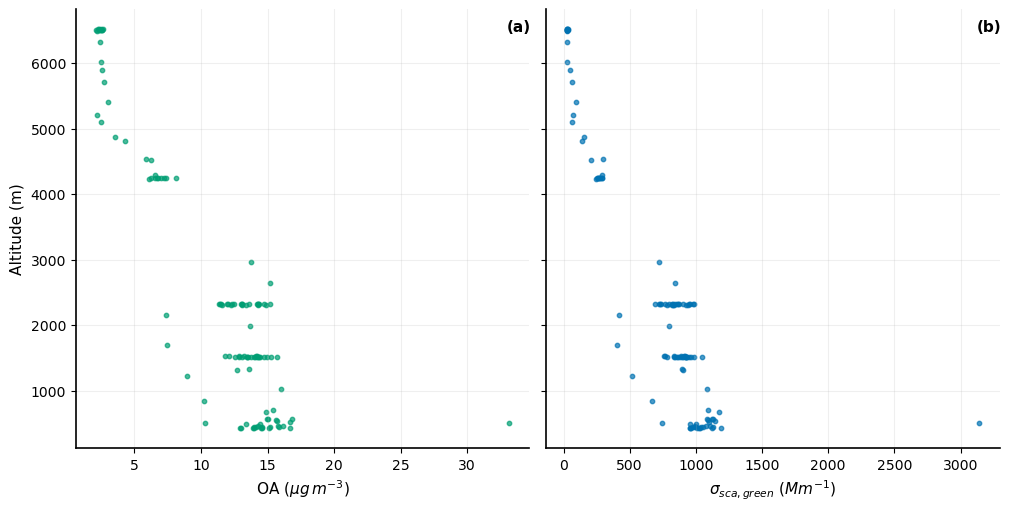

In [79]:
for flight in flights[0:1]:
    
    out = process_flight(flight)

    # First find common times between neph and AMS
    #common_times = np.intersect1d(out.neph_resampled_time, out.ams_resampled_time)
    #print(out.ams.time.values)
    # Then intersect with AMS and core
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)

    Height = core_file_matched['GPS_ALT'].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    ORG = ams_resampled_matched['ORG'].values
    
    # ---------------------------
    # NEW PLOT (vertical profile)
    # ---------------------------
    fig, axes = plot_vertical_profile_v1(
        ORG = ORG,
        ALT = Height,
        TSC_GREEN = TSC_green*10e6      
    )